In [36]:
import numpy as np
import numpy.ma as ma
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [37]:
# create the set of sample arrays
# Set the parameters
num_arrays = 10
array_size = (10, 10)
values = [0, 1, 4, np.nan]

# Generate the numpy arrays
arrays = [np.random.choice(values, size=array_size) for _ in range(num_arrays)]

# Display the first array as an example
# arrays[0]

In [38]:
# Generate dates starting from Jan 1, 2024, with 12-day intervals
start_date = datetime(2024, 1, 1)
dates = [start_date + timedelta(days=i * 12) for i in range(num_arrays)]

# Display the generated dates
dates

[datetime.datetime(2024, 1, 1, 0, 0),
 datetime.datetime(2024, 1, 13, 0, 0),
 datetime.datetime(2024, 1, 25, 0, 0),
 datetime.datetime(2024, 2, 6, 0, 0),
 datetime.datetime(2024, 2, 18, 0, 0),
 datetime.datetime(2024, 3, 1, 0, 0),
 datetime.datetime(2024, 3, 13, 0, 0),
 datetime.datetime(2024, 3, 25, 0, 0),
 datetime.datetime(2024, 4, 6, 0, 0),
 datetime.datetime(2024, 4, 18, 0, 0)]

In [5]:
from pathlib import Path
from datetime import datetime
import numpy as np
from typing import Optional, Tuple

def collect_confirmation(
    dist_status_latest: np.ndarray,
    dist_product_date: datetime,
    prev_consecutive_dist_count: Optional[np.ndarray] = None,
    prev_dist_product_date: Optional[datetime] = None,
    prev_first_conf_date: Optional[np.ndarray] = None,
    prev_observation_num: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Identifies confirmed disturbances in a 2D array by tracking consecutive occurrences over time.

    Parameters
    ----------
    dist_status_latest : np.ndarray
        2D array of disturbance status values (e.g., 0, 1, 4, or NaN).
    dist_product_date : datetime
        Date corresponding to the current product.
    prev_consecutive_dist_count : Optional[np.ndarray], default=None
        Array tracking previous consecutive disturbance counts.
    prev_dist_product_date : Optional[datetime], default=None
        Date of the previous disturbance product.
    prev_first_conf_date : Optional[np.ndarray], default=None
        Array of the first confirmation dates for each pixel.
    prev_observation_num : Optional[np.ndarray], default=None
        Number of valid observations seen so far per pixel.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]
        observation_num : np.ndarray
            Number of valid observations per pixel.
        consecutive_dist_count : np.ndarray
            Count of consecutive disturbance occurrences.
        confirmed_dist : np.ndarray
            Binary mask where 1 indicates a confirmed disturbance.
        first_confirmed_date : np.ndarray
            Days since start for first confirmed disturbance per pixel.
        latest_confirmed_date : np.ndarray
            Days since start for latest confirmed disturbance per pixel.
    """
    
    dist_s1_start_date = datetime(2024, 1, 1)
    days_since_start = (dist_product_date - dist_s1_start_date).days
    days_since_start_arr = np.full(dist_status_latest.shape, days_since_start)
    non_empty_pixels = (~np.isnan(dist_status_latest)).astype(int)

    # Handle initial acquisition
    if days_since_start < 12:
        print(f"Acquisition closest to start date: {dist_product_date.strftime('%b %d, %Y')}")
        confirmed_dist = np.zeros_like(dist_status_latest)
        consecutive_dist_count = (dist_status_latest >= 1).astype(int)
        first_confirmed_date = np.zeros_like(days_since_start_arr)
        latest_confirmed_date = np.zeros_like(days_since_start_arr)
        observation_num = np.ones_like(days_since_start_arr)

        return observation_num, consecutive_dist_count, confirmed_dist, first_confirmed_date, latest_confirmed_date

    # Ensure required previous data is available
    if any(x is None for x in [prev_consecutive_dist_count, prev_dist_product_date, prev_first_conf_date, prev_observation_num]):
        raise ValueError("Previous product data must be provided for non-initial acquisitions.")

    if prev_dist_product_date >= dist_product_date:
        raise ValueError("Previous product date must be earlier than current product date.")

    # Compute output arrays
    observation_num = non_empty_pixels + prev_observation_num
    consecutive_dist_count = np.where(non_empty_pixels, non_empty_pixels + prev_consecutive_dist_count, 0)
    confirmed_dist = (consecutive_dist_count >= 3).astype(int)
    first_confirmed_date = np.where(consecutive_dist_count != 3, prev_first_conf_date, days_since_start_arr)
    latest_confirmed_date = np.where(confirmed_dist, days_since_start_arr, 0)

    return observation_num, consecutive_dist_count, confirmed_dist, first_confirmed_date, latest_confirmed_date

In [6]:
# Function to iterate over multiple time steps
def process_consecutive_products(arrays, dates):
    results = []
    consecutive_dist_count = None
    first_date_confirmed = None
    observation_num = None
    
    for i, (array, date) in enumerate(zip(arrays, dates)):
        prev_consecutive_dist_count = consecutive_dist_count if i > 0 else None
        prev_dist_product_date = dates[i - 1] if i > 0 else None
        
        result = collect_confirmation(array, date, prev_consecutive_dist_count, prev_dist_product_date, first_date_confirmed, observation_num)
        results.append(result)
        
        # Update tracking variables
        consecutive_dist_count = result[1]
        first_date_confirmed = result[3]
        observation_num = result[0]
        
    return results

In [7]:
# Plotting function to visualize results
def plot_disturbance_results(results):
    labels = ["Number of observations", "Consecutive disturbances", "Confirmed disturbance", "First confirmed date", "Latest confirmed date"]
    n_steps = len(results)
    fig, axes = plt.subplots(n_steps, len(labels), figsize=(20, 2 * n_steps))

    for i, (confirmed, latest, cumulative, pixel_occ, first_date) in enumerate(results):
        data_list = [confirmed, latest, cumulative, pixel_occ, first_date]
        for j, data in enumerate(data_list):
            ax = axes[i, j] if n_steps > 1 else axes[j]
            im = ax.imshow(data, cmap='BuGn_r', interpolation='none')
            ax.set_title(labels[j] if i == 0 else "")
            ax.set_xticks([])
            ax.set_yticks([])
            for (x, y), val in np.ndenumerate(data):
                ax.text(y, x, int(val), ha='center', va='center', color='black', fontsize=8)
    
    plt.tight_layout()
    plt.show()

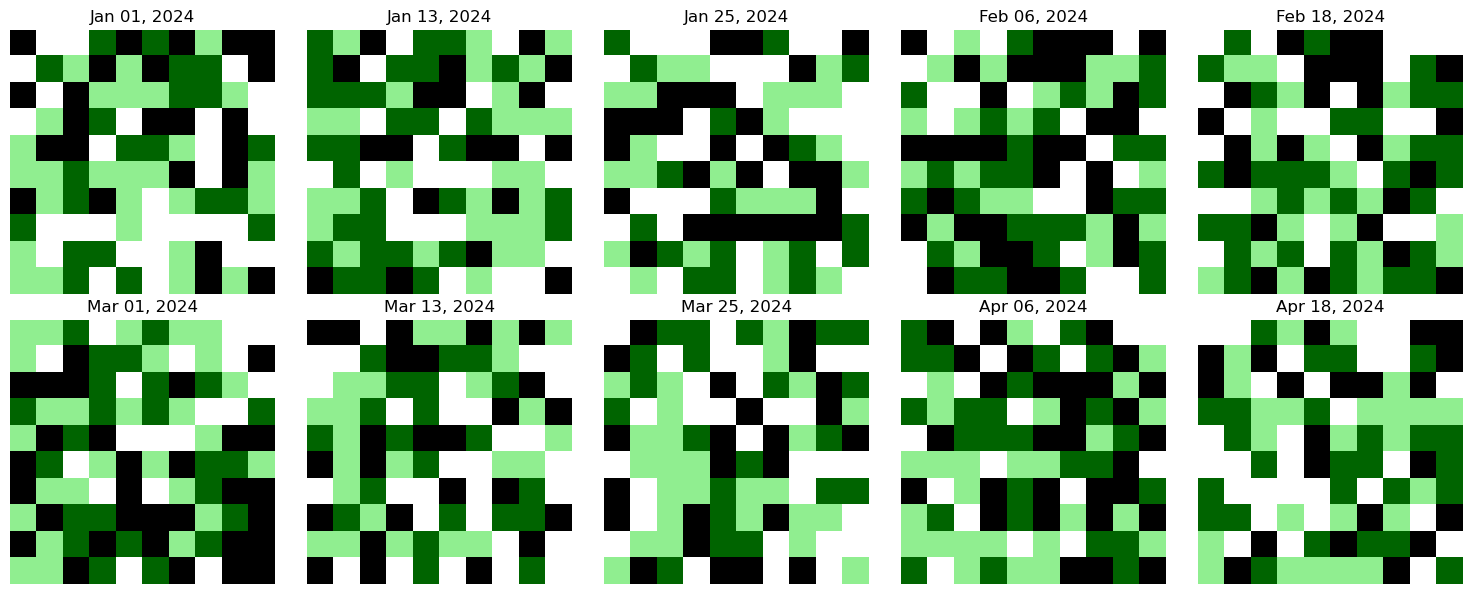

In [8]:
# Create a proper colormap where indices match 0 → black, 1 → light green, 4 → dark green
colors = ["black", "lightgreen", "black", "black", "darkgreen"]  # Index 2 and 3 are unused
custom_cmap = ListedColormap(colors)

# Create the plot
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    masked_array = ma.masked_invalid(arrays[i])  # Mask NaNs (they become transparent)

    ax.imshow(masked_array, cmap=custom_cmap, vmin=0, vmax=4)  # Ensure correct value mapping
    ax.set_title(dates[i].strftime("%b %d, %Y"))
    ax.axis("off")

plt.tight_layout()
plt.show()

Acquisition closest to start date: Jan 01, 2024


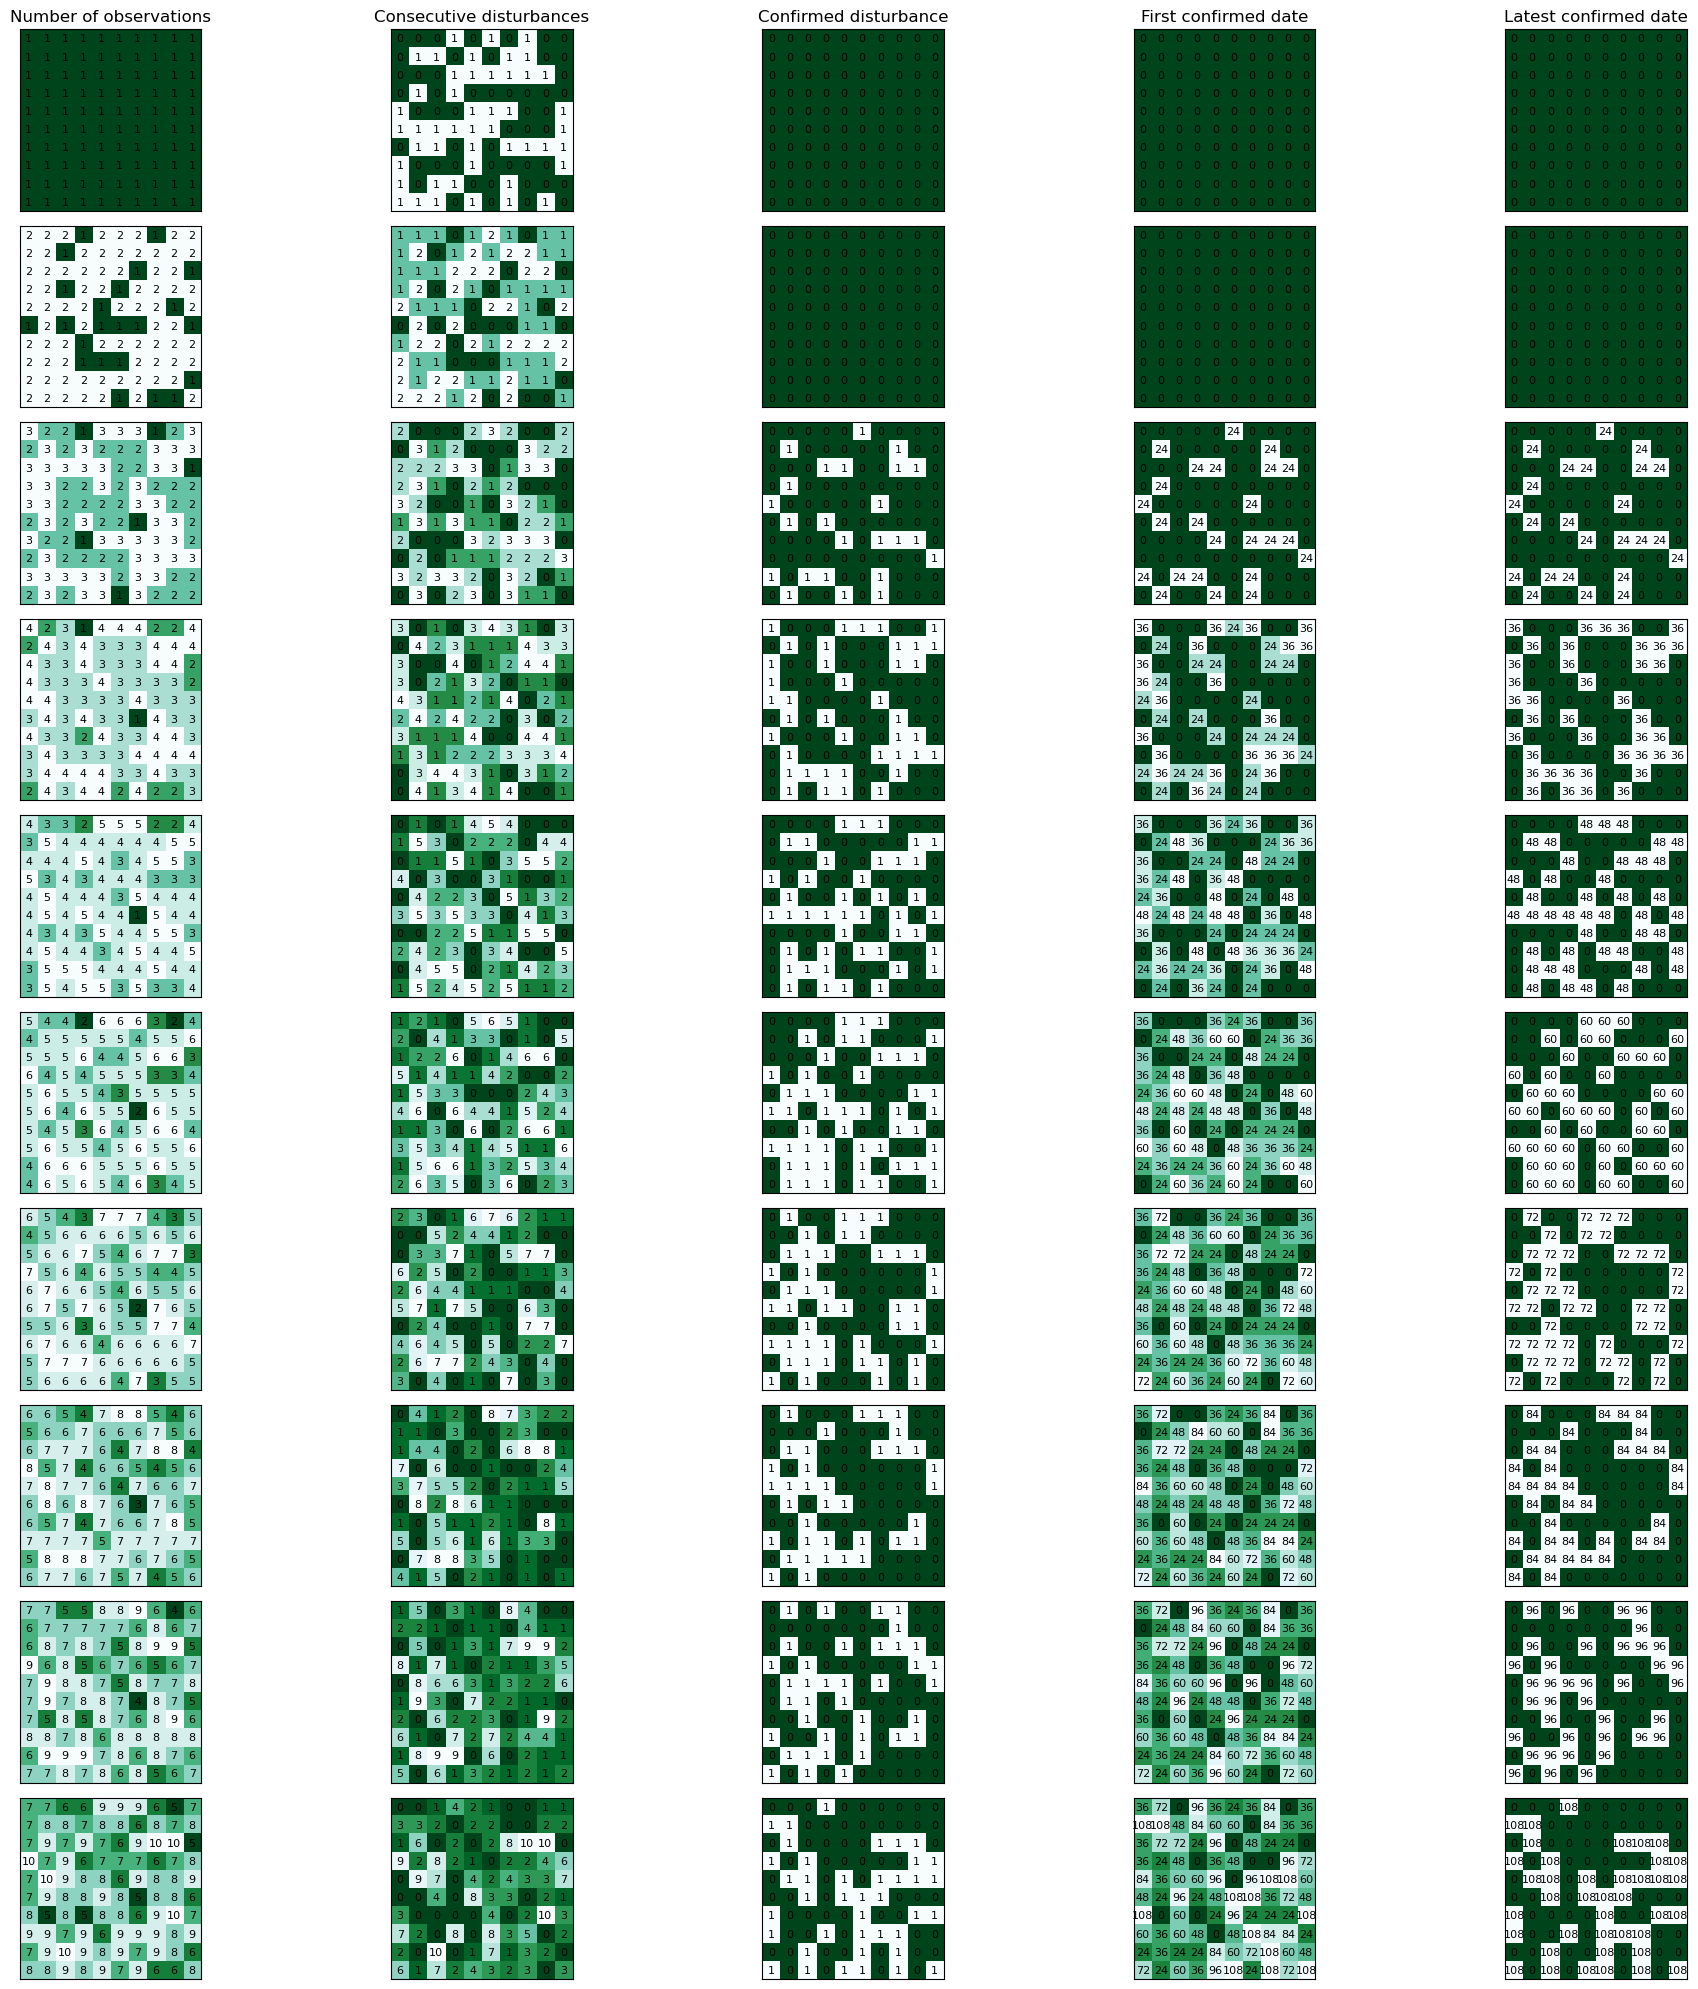

In [9]:
resutls = process_consecutive_products(arrays, dates)
plot_disturbance_results(resutls)

### DIST-HLS-like implementation

In [3]:
from pathlib import Path
import rasterio
from rasterio.windows import Window
from typing import List, Tuple, Optional

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [4]:
# Read and subset metrics
data_dir = Path("/Users/cabrera/Desktop/spain_flood_dists")
metric_paths = sorted(list(data_dir.glob("OPERA*/*_GEN-METRIC.tif")))
metric_paths

[PosixPath('/Users/cabrera/Desktop/spain_flood_dists/OPERA_L3_DIST-ALERT-S1_T30SYJ_20240110T000000Z_20250226T000000Z_S1_30_v0.1/OPERA_L3_DIST-ALERT-S1_T30SYJ_20240110T000000Z_20250226T000000Z_S1_30_v0.1_GEN-METRIC.tif'),
 PosixPath('/Users/cabrera/Desktop/spain_flood_dists/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241031T180259Z_20250226T095718Z_S1_30_v0.1/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241031T180259Z_20250226T095718Z_S1_30_v0.1_GEN-METRIC.tif'),
 PosixPath('/Users/cabrera/Desktop/spain_flood_dists/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241106T061030Z_20250225T174139Z_S1_30_v0.1/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241106T061030Z_20250225T174139Z_S1_30_v0.1_GEN-METRIC.tif'),
 PosixPath('/Users/cabrera/Desktop/spain_flood_dists/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241107T175447Z_20250225T183623Z_S1_30_v0.1/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241107T175447Z_20250225T183623Z_S1_30_v0.1_GEN-METRIC.tif'),
 PosixPath('/Users/cabrera/Desktop/spain_flood_dists/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241112T180258Z_20250226T091931Z

In [5]:
# confidence 
# confidence = N**2 * Max(metric)
confidence_threshold = 3**2 * 3.5
confidence_threshold

31.5

In [8]:
# Extract date from filenames
def extract_date_from_filename(file_path: str) -> datetime:
    """
    Extracts the date from the filename based on a specific pattern.
    
    :param file_path: The full path of the file.
    :return: The extracted date as a datetime object.
    """
    # Get the filename from the full file path
    filename = Path(file_path).name
    
    # Split the filename by underscores and extract the fourth item
    date_str = filename.split("_")[4]  # Assuming the fourth item is the date
    
    # Parse the date string into a datetime object
    return datetime.strptime(date_str, "%Y%m%dT%H%M%SZ")

In [9]:
dist_product_dates = [extract_date_from_filename(str(path)) for path in metric_paths]
dist_product_dates
# Read the raster data and subset it

[datetime.datetime(2024, 1, 10, 0, 0),
 datetime.datetime(2024, 10, 31, 18, 2, 59),
 datetime.datetime(2024, 11, 6, 6, 10, 30),
 datetime.datetime(2024, 11, 7, 17, 54, 47),
 datetime.datetime(2024, 11, 12, 18, 2, 58),
 datetime.datetime(2024, 11, 13, 6, 2, 21)]

In [10]:
# Visualize and set subset
# with rasterio.open(metric_paths[0]) as src:
#     band1 = src.read(1)

# plt.figure(figsize=(8, 6))
# plt.imshow(band1[1150:1350, 800:1000], cmap='gray')
# plt.title(f"First Band of {metric_paths[0].name}")
# plt.colorbar(label="Pixel Values")
# # plt.axis('off')
# plt.show()

In [11]:
def read_subset_tifs(
    tiff_paths: List[Path],
    subset_window: Optional[Tuple[int, int, int, int]] = None  # (row_off, col_off, height, width)
) -> np.ndarray:
    """
    Reads a list of TIFF files, applies a subset window, and returns a stacked numpy array.

    Parameters:
        tiff_paths (List[Path]): List of paths to TIFF files.
        subset_window (Optional[Tuple[int, int, int, int]]): Window to subset (row_off, col_off, height, width).

    Returns:
        np.ndarray: Array of shape (num_files, height, width)
    """
    arrays = []

    for path in tiff_paths:
        with rasterio.open(path) as src:
            if subset_window:
                window = Window(*subset_window)
                data = src.read(1, window=window)  # Read the first band as a 2D array
            else:
                data = src.read(1)  # Read the first band as a 2D array
        arrays.append(data)

    return arrays

In [12]:
# Define your subset
# For subset [1150:1350, 800:1000], we get the following:
subset = (800, 1150, 200, 200)  # (x offset, y_offset, height, width)
# Read and stack the TIFFs with the specified subset window
metric_arrays = read_subset_tifs(metric_paths, subset_window=subset)
print("Stacked array shape:", len(metric_arrays))

Stacked array shape: 6


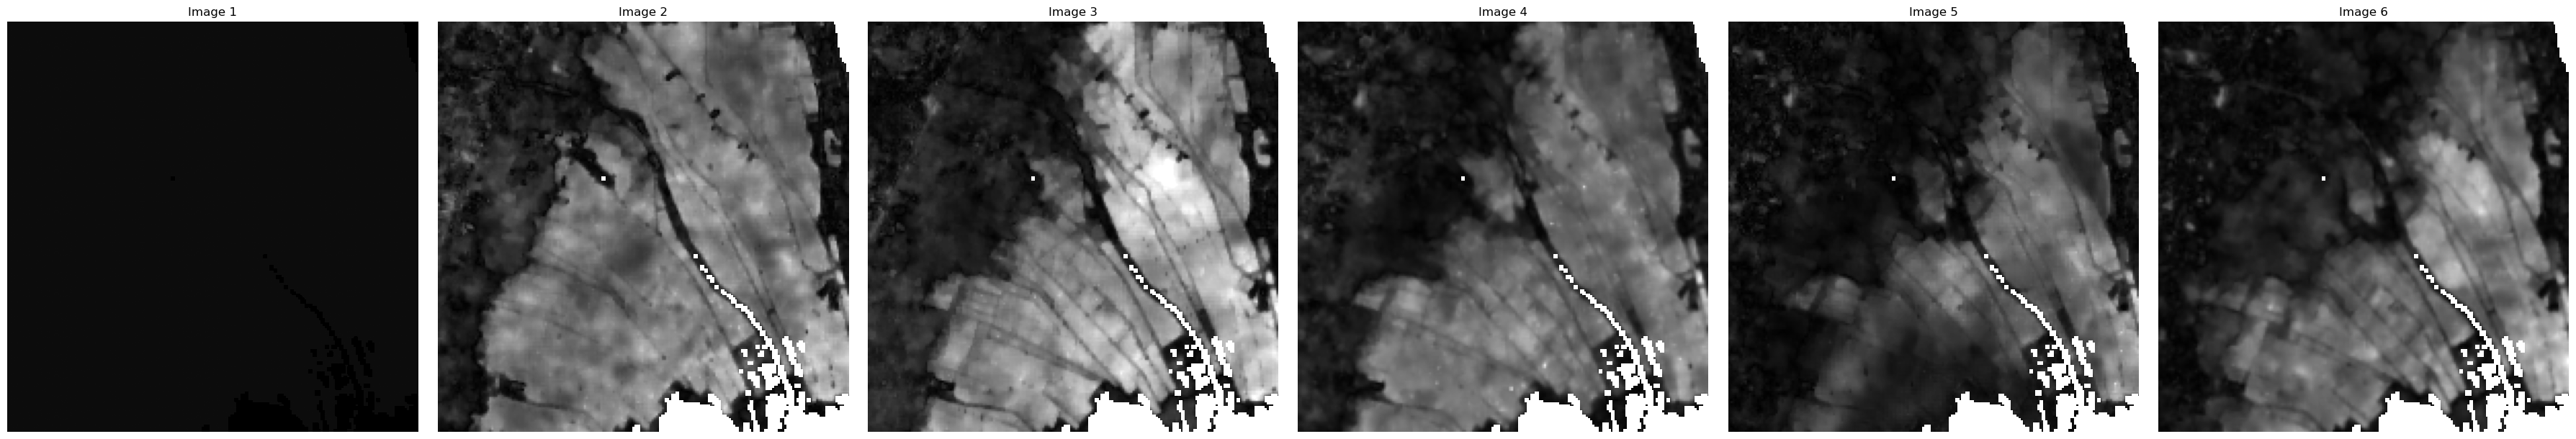

In [13]:
# Create a figure with subplots aligned horizontally
num_files = len(metric_arrays)

# Create a figure with subplots aligned horizontally
fig, axes = plt.subplots(1, num_files, figsize=(num_files * 6, 6))

# If there's only one image, axes will be a single axis, so we handle both cases
if num_files == 1:
    axes = [axes]

# Plot each 2D array in the list
for i, ax in enumerate(axes):
    ax.imshow(metric_arrays[i], vmin=0, vmax=20, cmap='gray')  # Display the 2D array in grayscale
    ax.set_title(f"Image {i+1}")
    ax.axis('off')  # Hide axis for cleaner visualization

# Adjust layout for tight spacing
plt.tight_layout()
plt.show()

In [14]:
from pathlib import Path
from datetime import datetime
import numpy as np
from typing import Optional, Tuple

def collect_confirmation_hlslike(
    dist_metric: np.ndarray,
    dist_product_date: datetime,
    prev_consecutive_dist_count: Optional[np.ndarray] = None,
    prev_dist_product_date: Optional[datetime] = None,
    prev_first_conf_date: Optional[np.ndarray] = None,
    prev_observation_num: Optional[np.ndarray] = None,
    prev_max_metric: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Identifies confirmed disturbances in a 2D array by tracking consecutive occurrences over time.

    Parameters
    ----------
    dist_status_latest : np.ndarray
        2D array of disturbance status values (e.g., 0, 1, 4, or NaN).
    dist_product_date : datetime
        Date corresponding to the current product.
    prev_consecutive_dist_count : Optional[np.ndarray], default=None
        Array tracking previous consecutive disturbance counts.
    prev_dist_product_date : Optional[datetime], default=None
        Date of the previous disturbance product.
    prev_first_conf_date : Optional[np.ndarray], default=None
        Array of the first confirmation dates for each pixel.
    prev_observation_num : Optional[np.ndarray], default=None
        Number of valid observations seen so far per pixel.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]
        observation_num : np.ndarray
            Number of valid observations per pixel.
        consecutive_dist_count : np.ndarray
            Count of consecutive disturbance occurrences.
        confirmed_dist : np.ndarray
            Binary mask where 1 indicates a confirmed disturbance.
        first_confirmed_date : np.ndarray
            Days since start for first confirmed disturbance per pixel.
        latest_confirmed_date : np.ndarray
            Days since start for latest confirmed disturbance per pixel.
    """
    
    dist_s1_start_date = datetime(2024, 1, 1)
    days_since_start = (dist_product_date - dist_s1_start_date).days
    days_since_start_arr = np.full(dist_metric.shape, days_since_start)
    non_empty_pixels = (~np.isnan(dist_metric)).astype(int)

    # Handle initial acquisition
    if days_since_start < 12:
        print(f"Acquisition closest to start date: {dist_product_date.strftime('%b %d, %Y')}")
        confirmed_dist = np.zeros_like(dist_metric)
        consecutive_dist_count = (dist_metric >= 3.5).astype(int)
        first_confirmed_date = np.zeros_like(days_since_start_arr)
        latest_confirmed_date = np.zeros_like(days_since_start_arr)
        observation_num = np.ones_like(days_since_start_arr)
        max_metric = np.copy(dist_metric)
        confidence = np.zeros_like(dist_metric)

        return observation_num, consecutive_dist_count, confirmed_dist, first_confirmed_date, latest_confirmed_date, max_metric, confidence
    # Ensure required previous data is available
    if any(x is None for x in [prev_consecutive_dist_count, prev_dist_product_date, prev_first_conf_date, prev_observation_num]):
        raise ValueError("Previous product data must be provided for non-initial acquisitions.")

    if prev_dist_product_date >= dist_product_date:
        raise ValueError("Previous product date must be earlier than current product date.")

    # Compute output arrays
    observation_num = non_empty_pixels + prev_observation_num
    consecutive_dist_count = np.where(non_empty_pixels, non_empty_pixels + prev_consecutive_dist_count, 0)
    confirmed_dist = (consecutive_dist_count >= 3).astype(int)
    first_confirmed_date = np.where(consecutive_dist_count != 3, prev_first_conf_date, days_since_start_arr)
    latest_confirmed_date = np.where(confirmed_dist, days_since_start_arr, 0)
    max_metric = np.fmax(dist_metric, prev_max_metric)
    confidence = (observation_num ** 2) * max_metric 

    return observation_num, consecutive_dist_count, confirmed_dist, first_confirmed_date, latest_confirmed_date, max_metric, confidence

In [15]:
# Function to iterate over multiple time steps
def process_hls_confirm(arrays, dates):
    results = []
    consecutive_dist_count = None
    first_date_confirmed = None
    observation_num = None
    max_metric = None
    
    for i, (array, date) in enumerate(zip(arrays, dates)):
        prev_consecutive_dist_count = consecutive_dist_count if i > 0 else None
        prev_dist_product_date = dates[i - 1] if i > 0 else None
        prev_max_metric = max_metric if i > 0 else None
        
        result = collect_confirmation_hlslike(array, date, prev_consecutive_dist_count, prev_dist_product_date, first_date_confirmed, observation_num, prev_max_metric)
        results.append(result)
        
        # Update tracking variables
        consecutive_dist_count = result[1]
        first_date_confirmed = result[3]
        observation_num = result[0]
        max_metric = result[5]
        
    return results

In [26]:
def plot_disturbance_results(results):
    labels = ["Number of observations", "Consecutive disturbances", "Confirmed disturbance",
              "First confirmed date", "Latest confirmed date", "Max metric", "Confidence"]

    # Define manual min/max ranges for each variable (must match the labels order)
    value_ranges = [
        (0, 10),    # Number of observations
        (0, 10),    # Consecutive disturbances
        (0, 1),     # Confirmed disturbance (binary)
        (0, 200),  # First confirmed date (e.g., relative DOY or date index)
        (0, 200),  # Latest confirmed date
        (0, 30),   # Max metric
        (0, 100)      # Confidence value
    ]

    n_steps = len(results)
    fig, axes = plt.subplots(n_steps, len(labels), figsize=(22, 2.8 * n_steps))

    for i, (observation_num, consecutive_dist_count, confirmed_dist, first_confirmed_date, latest_confirmed_date, max_metric, confidence) in enumerate(results):
        data_list = [observation_num, consecutive_dist_count, confirmed_dist, first_confirmed_date, latest_confirmed_date, max_metric, confidence]

        for j, data in enumerate(data_list):
            ax = axes[i, j] if n_steps > 1 else axes[j]

            # Apply manual vmin/vmax
            vmin, vmax = value_ranges[j]

            im = ax.imshow(data, cmap='BuGn_r', interpolation='none', vmin=vmin, vmax=vmax)
            ax.set_title(labels[j] if i == 0 else "")
            ax.set_xticks([])
            ax.set_yticks([])

            # Add individual colorbar
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.show()

In [27]:
# observation_num, consecutive_dist_count, confirmed_dist, first_confirmed_date, latest_confirmed_date, max_metric, confidence

Acquisition closest to start date: Jan 10, 2024


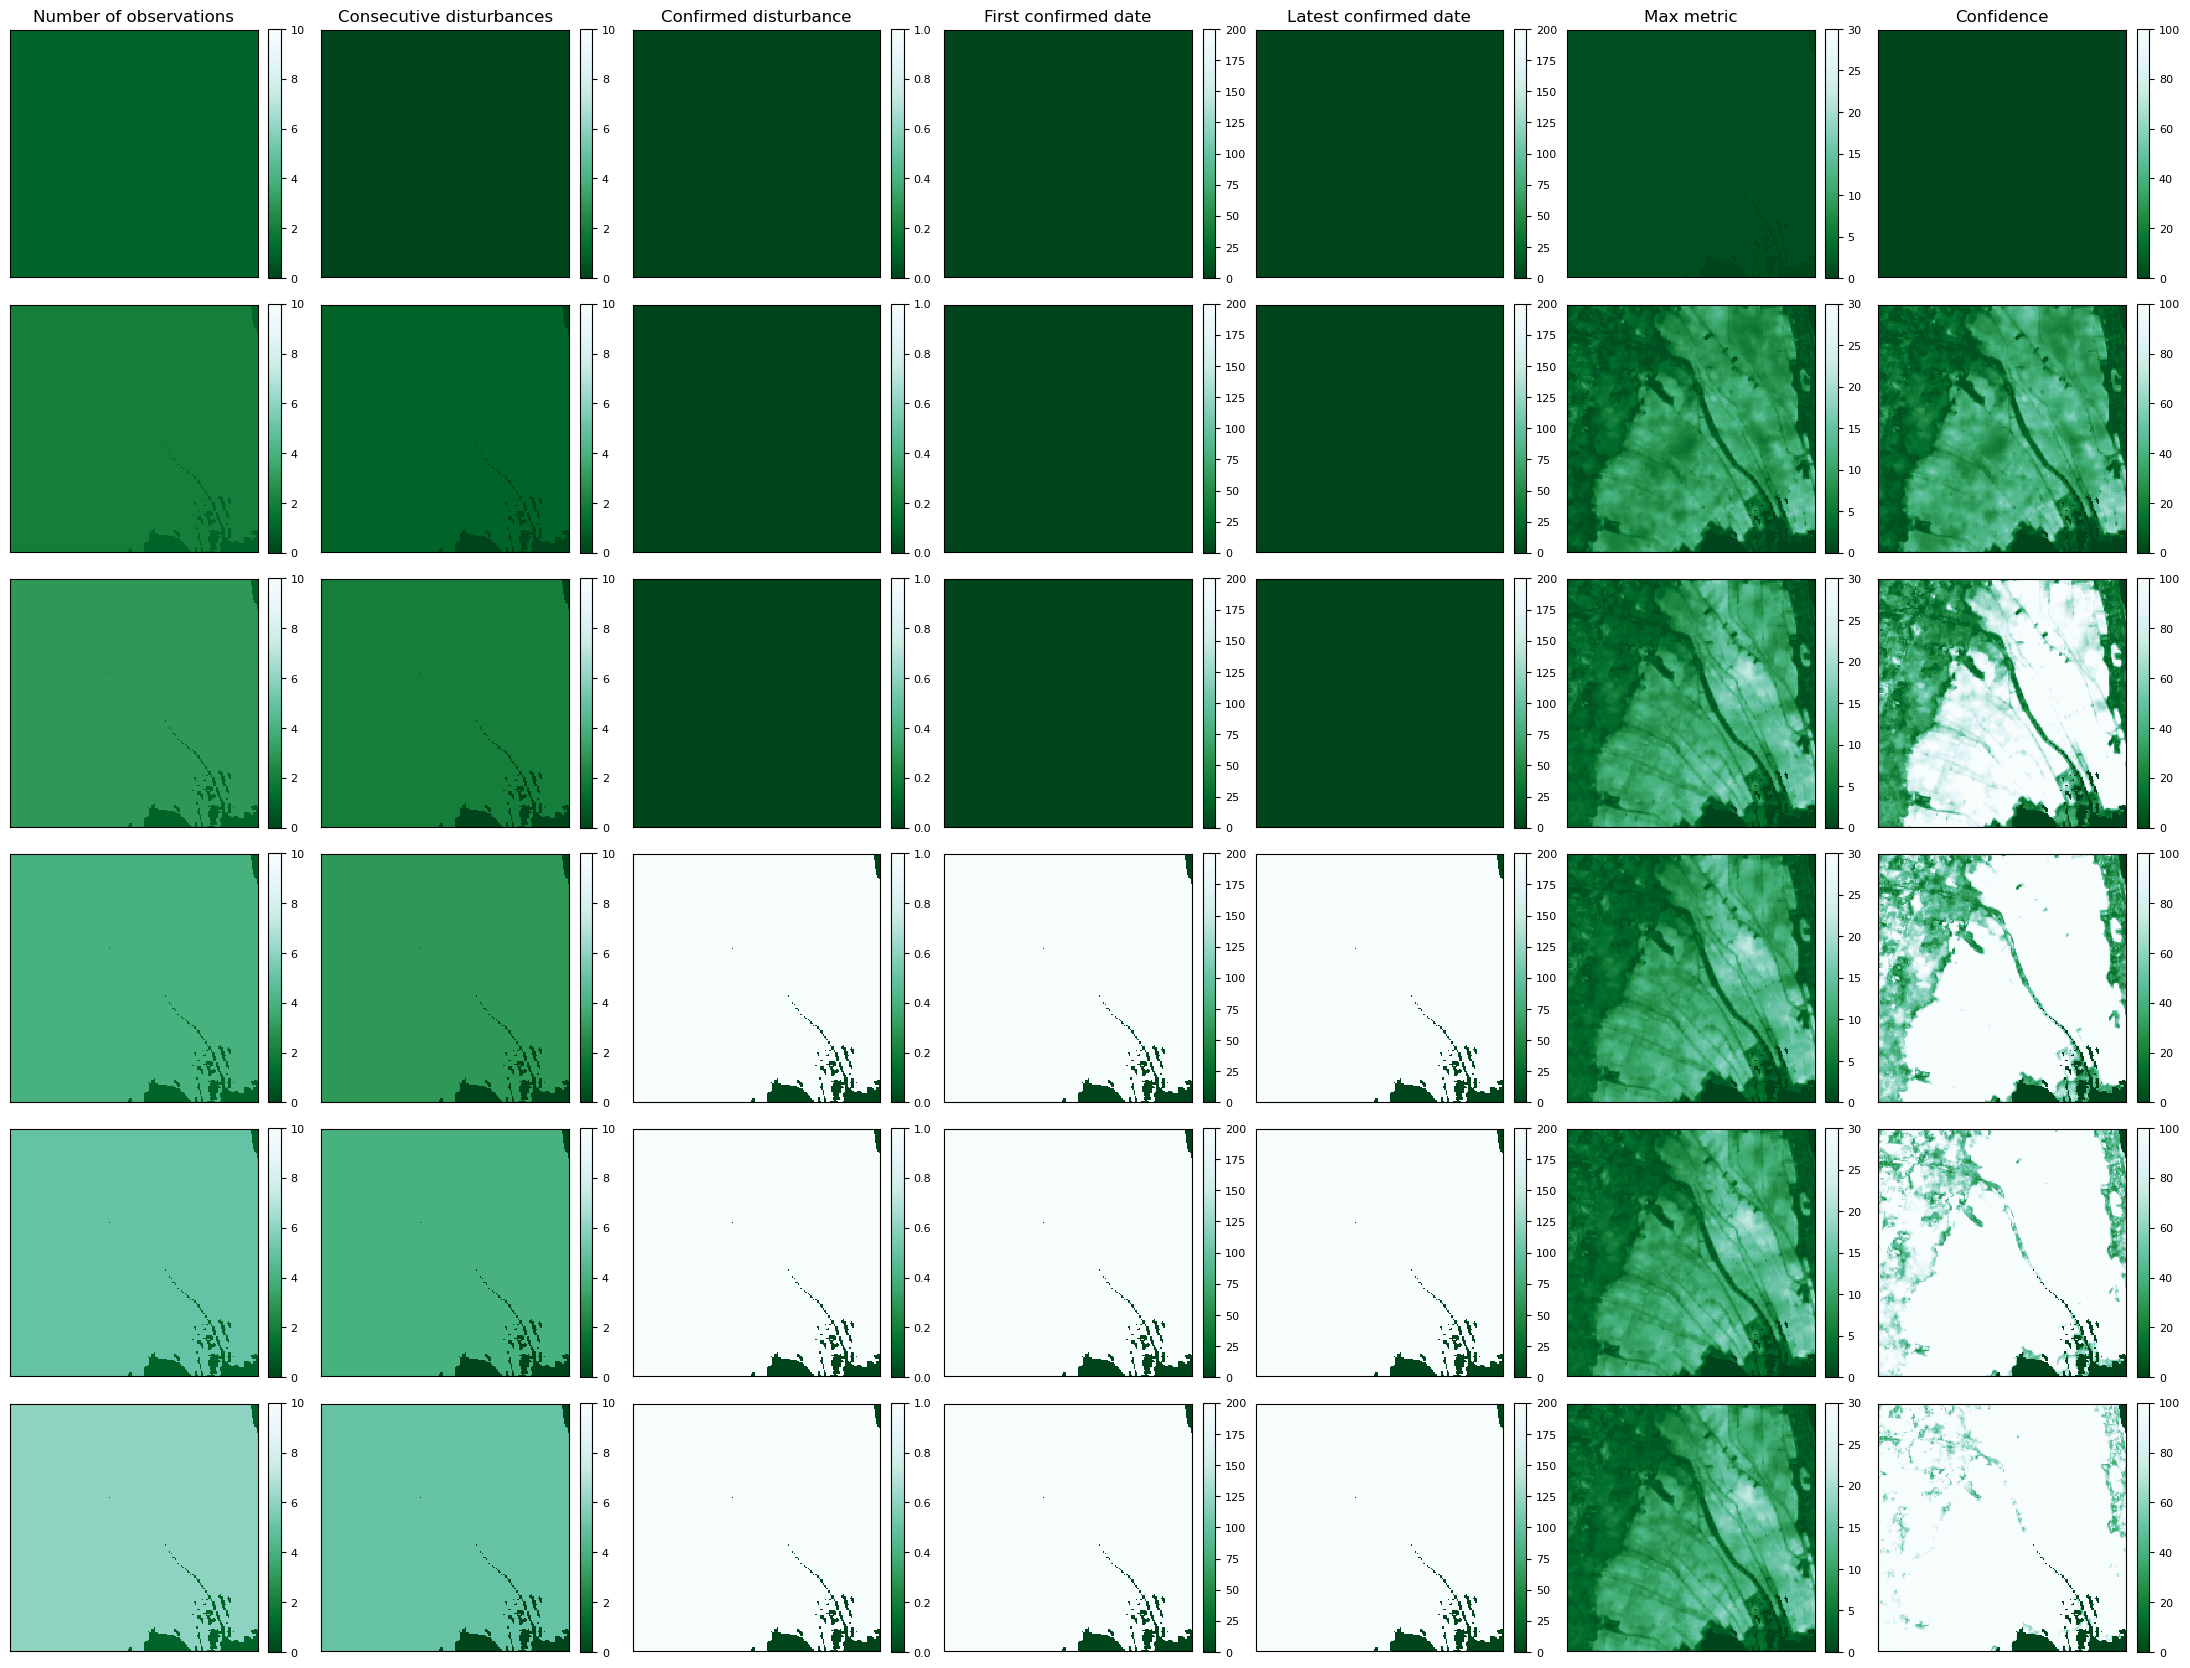

In [28]:
resutls = process_hls_confirm(metric_arrays, dist_product_dates)
plot_disturbance_results(resutls)

In [40]:
def generate_array_series(num_arrays=10, size=10, max_val=30):
    arrays = []

    # Create a 2D Gaussian centered in the middle
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    xv, yv = np.meshgrid(x, y)
    gauss = np.exp(-(xv**2 + yv**2) * 5)  # Sharper peak with factor 5
    gauss = gauss / gauss.max() * max_val

    for i in range(num_arrays):
        # Define a time-based visibility scale: 0 for arrays 0–2 and 8–9, full in 3–7
        if i < 3 or i > 7:
            scale = 0
        elif 3 <= i <= 5:
            scale = (i - 2) / 3  # ramps up from 0 to 1
        elif i == 6:
            scale = 1
        else:  # i == 7
            scale = 1 - (i - 6) / 2  # ramps down from 1 to 0

        frame = gauss * scale

        # Randomly apply NaNs to simulate missing data
        nan_mask = np.random.rand(size, size) < 0.1  # 10% NaNs
        frame[nan_mask] = np.nan

        arrays.append(frame)

    return arrays

# Example usage:
arrays = generate_array_series()

# # Optional: visualize a few frames
# for i, arr in enumerate(arrays):
#     plt.imshow(arr, cmap='hot', interpolation='nearest')
#     plt.title(f'Array {i}')
#     plt.colorbar()
#     plt.show()


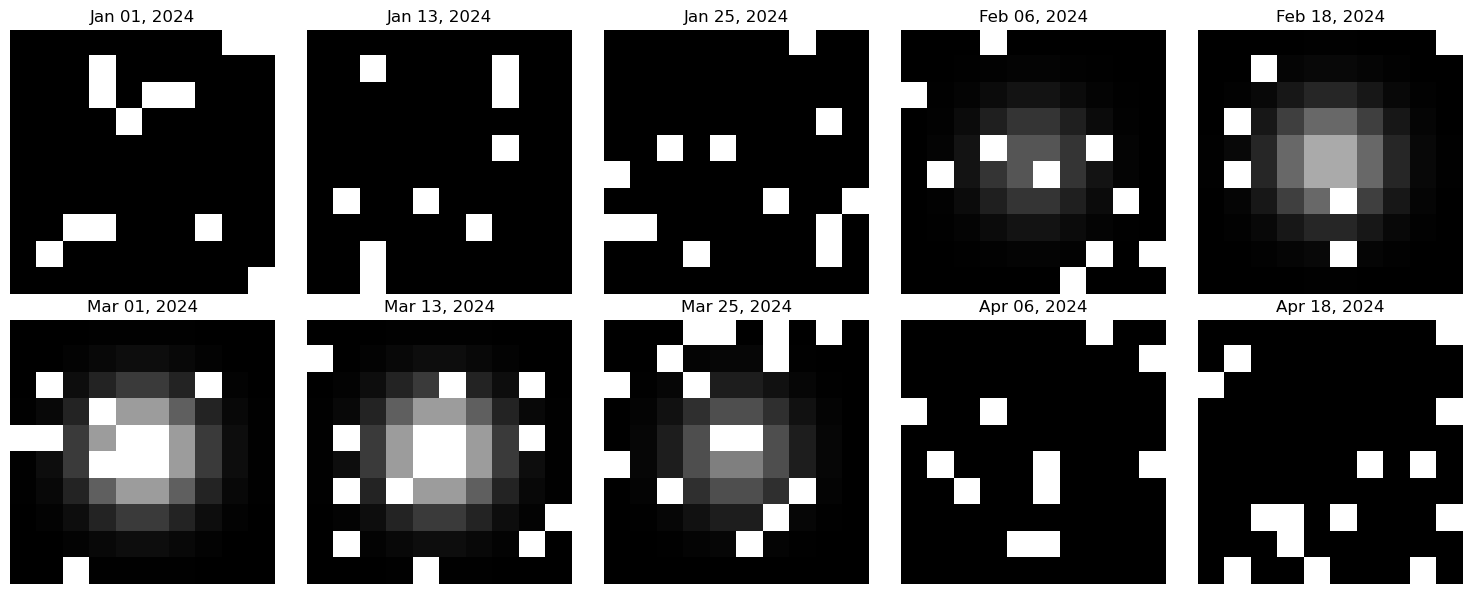

In [41]:
# Create a proper colormap where indices match 0 → black, 1 → light green, 4 → dark green

# Create the plot
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(arrays[i], cmap='gray', vmin=0, vmax=30)  # Ensure correct value mapping
    ax.set_title(dates[i].strftime("%b %d, %Y"))
    ax.axis("off")

plt.tight_layout()
plt.show()

Acquisition closest to start date: Jan 01, 2024


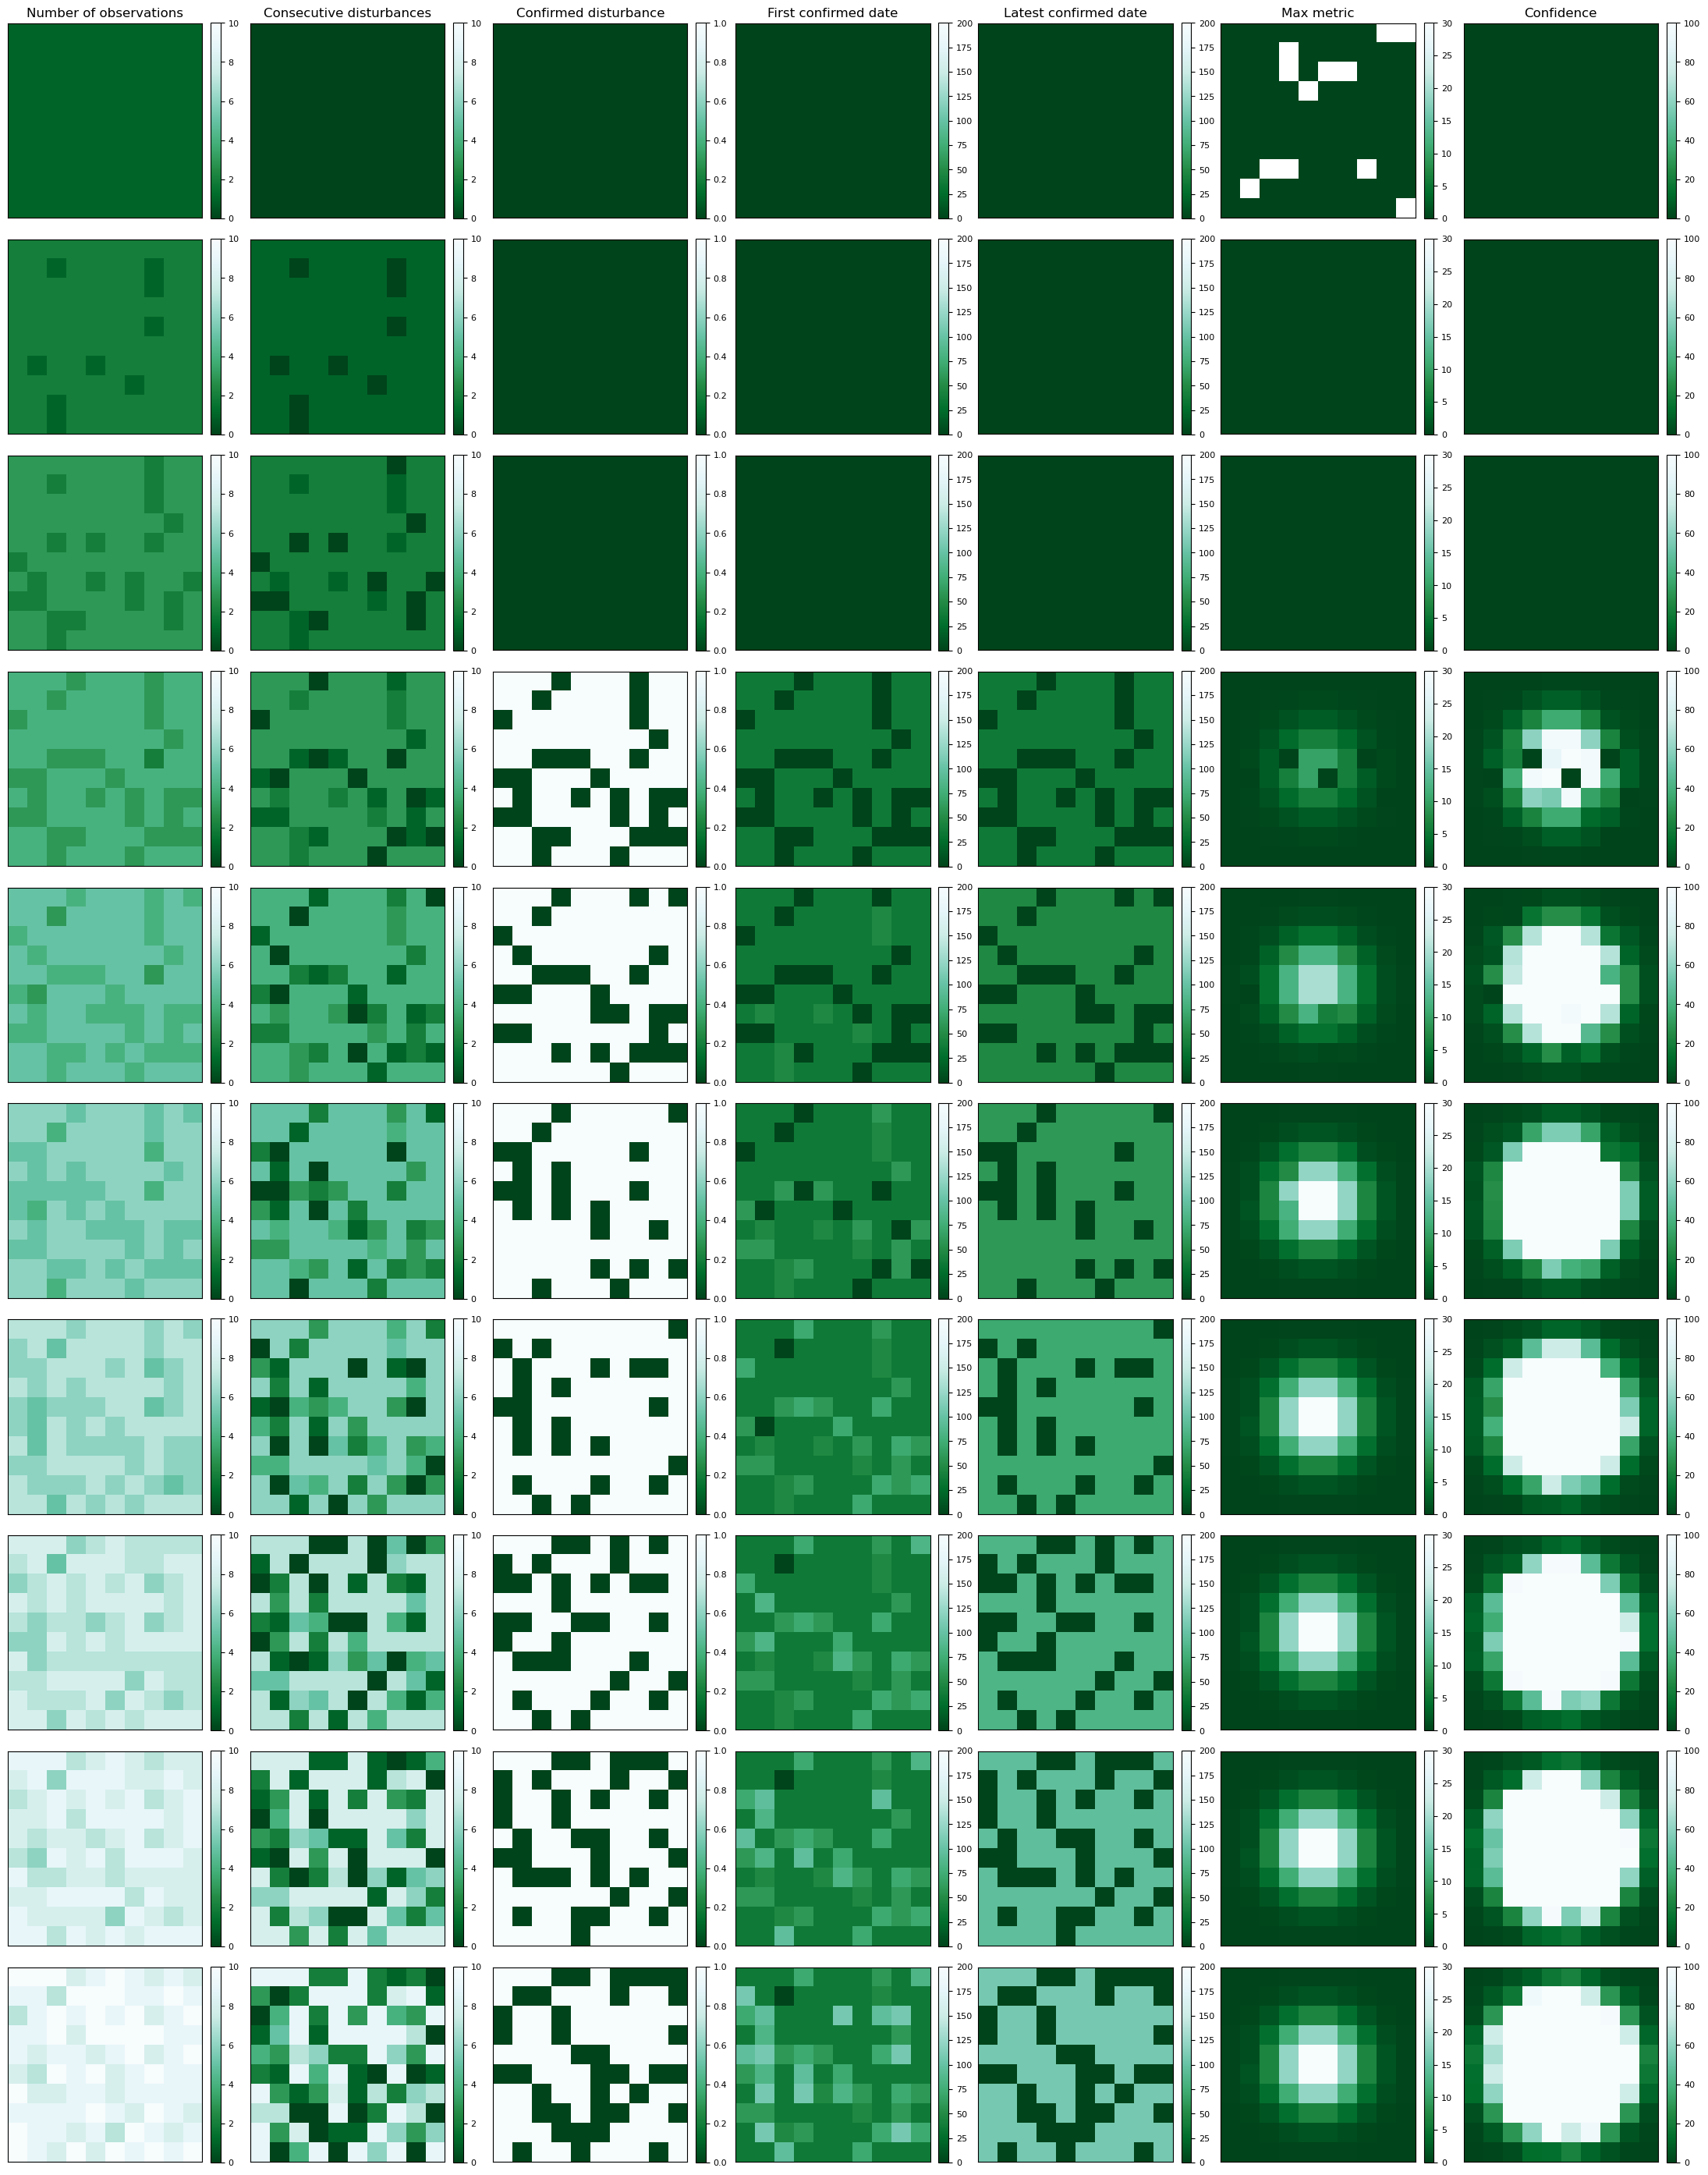

In [42]:
resutls = process_hls_confirm(arrays, dates)
plot_disturbance_results(resutls)